In [1]:
!python -V

Python 3.9.0


In [2]:
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_squared_error

In [4]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000/")
mlflow.set_experiment("nyc-new-brand-experiment_first")

<Experiment: artifact_location='mlflow-artifacts:/602191714386844847', creation_time=1748263764364, experiment_id='602191714386844847', last_update_time=1748263764364, lifecycle_stage='active', name='nyc-new-brand-experiment_first', tags={}>

In [5]:
# read parquet file
df = pd.read_parquet('./../data/green_tripdata_2021-01.parquet')
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.5,0.5,0.5,0.00,0.0,None,0.3,6.80,2.0,1.0,0.00
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.0,0.5,0.5,2.81,0.0,None,0.3,16.86,1.0,1.0,2.75
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.0,0.5,0.5,1.00,0.0,None,0.3,8.30,1.0,1.0,0.00
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.0,0.5,0.5,0.00,0.0,None,0.3,9.30,2.0,1.0,0.00
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.0,0.0,-0.5,0.00,0.0,None,-0.3,-52.80,3.0,1.0,0.00


In [6]:
df.describe()

,VendorID,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,76518.000000,40471.000000,76518.000000,76518.000000,40471.000000,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000,40471.000000,40471.000000,40471.000000
mean,1.905290,1.143041,109.590371,130.685577,1.192311,40.862552,19.939777,0.740462,0.254104,1.506499,0.546209,0.298142,23.574820,1.406958,1.030590,0.613828
std,0.292816,0.878693,71.063053,77.101641,0.756395,1924.408778,14.984241,1.184429,0.251467,1.877930,1.876162,0.029243,16.361991,0.517005,0.172206,1.145076
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,-280.000000,-5.500000,-0.500000,-9.450000,0.000000,-0.300000,-280.300000,1.000000,1.000000,0.000000
25%,2.000000,1.000000,55.000000,65.000000,1.000000,1.300000,9.000000,0.000000,0.000000,0.000000,0.000000,0.300000,11.800000,1.000000,1.000000,0.000000
50%,2.000000,1.000000,76.000000,129.000000,1.000000,2.590000,16.730000,0.000000,0.500000,1.160000,0.000000,0.300000,20.640000,1.000000,1.000000,0.000000
75%,2.000000,1.000000,166.000000,197.000000,1.000000,5.760000,25.500000,1.000000,0.500000,2.750000,0.000000,0.300000,29.320000,2.000000,1.000000,0.000000
max,2.000000,99.000000,265.000000,265.000000,8.000000,244152.010000,284.000000,8.250000,0.500000,110.000000,31.250000,0.300000,294.510000,5.000000,2.000000,2.750000


In [7]:
# add duration column
df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime

#converting the duration to a minutes
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)
df = df[(df.duration >= 1) & (df.duration <= 60)]
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.50,...,0.5,0.00,0.00,None,0.3,6.80,2.0,1.0,0.00,3.933333
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.00,...,0.5,2.81,0.00,None,0.3,16.86,1.0,1.0,2.75,8.750000
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.00,...,0.5,1.00,0.00,None,0.3,8.30,1.0,1.0,0.00,5.966667
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.00,...,0.5,0.00,0.00,None,0.3,9.30,2.0,1.0,0.00,7.083333
7,2,2021-01-01 00:26:31,2021-01-01 00:28:50,N,1.0,75,75,6.0,0.45,3.50,...,0.5,0.96,0.00,None,0.3,5.76,1.0,1.0,0.00,2.316667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76513,2,2021-01-31 21:38:00,2021-01-31 22:16:00,None,NaN,81,90,NaN,17.63,56.23,...,0.0,0.00,6.12,None,0.3,65.40,NaN,NaN,NaN,38.000000
76514,2,2021-01-31 22:43:00,2021-01-31 23:21:00,None,NaN,35,213,NaN,18.36,46.66,...,0.0,12.20,6.12,None,0.3,65.28,NaN,NaN,NaN,38.000000
76515,2,2021-01-31 22:16:00,2021-01-31 22:27:00,None,NaN,74,69,NaN,2.50,18.95,...,0.0,0.00,0.00,None,0.3,22.00,NaN,NaN,NaN,11.000000
76516,2,2021-01-31 23:10:00,2021-01-31 23:37:00,None,NaN,168,215,NaN,14.48,48.87,...,0.0,0.00,6.12,None,0.3,58.04,NaN,NaN,NaN,27.000000


In [8]:
df.duration.describe()

count    73908.000000
mean        16.852578
std         11.563163
min          1.000000
25%          8.050000
50%         14.000000
75%         22.633333
max         60.000000
Name: duration, dtype: float64

In [9]:
df.duration.describe(percentiles = [0.95, 0.98, 0.99])

count    73908.000000
mean        16.852578
std         11.563163
min          1.000000
50%         14.000000
95%         41.000000
98%         48.781000
99%         53.000000
max         60.000000
Name: duration, dtype: float64

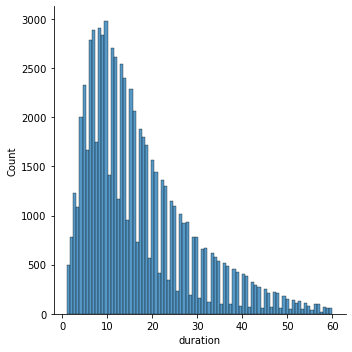

In [11]:
sns.displot(df.duration)

In [12]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [13]:
train_dicts = df[categorical + numerical].to_dict(orient='records')
train_dicts

[{'PULocationID': '43', 'DOLocationID': '151', 'trip_distance': 1.01},
 {'PULocationID': '166', 'DOLocationID': '239', 'trip_distance': 2.53},
 {'PULocationID': '41', 'DOLocationID': '42', 'trip_distance': 1.12},
 {'PULocationID': '168', 'DOLocationID': '75', 'trip_distance': 1.99},
 {'PULocationID': '75', 'DOLocationID': '75', 'trip_distance': 0.45},
 {'PULocationID': '225', 'DOLocationID': '265', 'trip_distance': 12.19},
 {'PULocationID': '244', 'DOLocationID': '244', 'trip_distance': 3.39},
 {'PULocationID': '75', 'DOLocationID': '213', 'trip_distance': 6.69},
 {'PULocationID': '74', 'DOLocationID': '238', 'trip_distance': 2.34},
 {'PULocationID': '74', 'DOLocationID': '60', 'trip_distance': 5.48},
 {'PULocationID': '42', 'DOLocationID': '41', 'trip_distance': 0.9},
 {'PULocationID': '74', 'DOLocationID': '116', 'trip_distance': 2.08},
 {'PULocationID': '116', 'DOLocationID': '143', 'trip_distance': 4.64},
 {'PULocationID': '75', 'DOLocationID': '42', 'trip_distance': 1.68},
 {'PULo

In [14]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

mean_squared_error(y_train, y_pred, squared=False)

9.775464552087287

/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


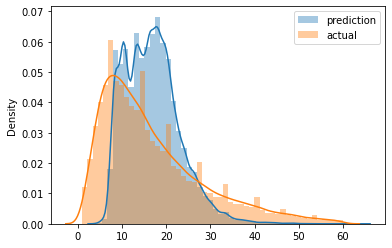

In [15]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend()

In [5]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [6]:
df_train = read_dataframe('./../data/green_tripdata_2021-01.parquet')
df_val = read_dataframe('./../data/green_tripdata_2021-02.parquet')

In [7]:
len(df_train), len(df_val)

(73908, 61921)

In [8]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [9]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [10]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

mean_squared_error(y_val, y_pred, squared=False)

7.479562160810692

In [12]:
with open('./../models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [11]:
# Tacking experiment in MLFlow

with mlflow.start_run():
    
    mlflow.set_tag("developer", "moshifa")
    mlflow.log_param("tain data path","./data/green_tripdata_2021-01.parquet")
    mlflow.log_param("val data path", "./data/green_tripdata_2021-02.parquet")
    
    alpha = 0.01
    mlflow.log_param("alpha", alpha)

    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)

    rmse = mean_squared_error(y_val, y_pred, squared=False)
    mlflow.log_metric("rmse", rmse)

🏃 View run bustling-lynx-962 at: http://127.0.0.1:5000/#/experiments/602191714386844847/runs/fe2307b474c543c7bf9d729d506aaa2a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/602191714386844847


## Training Xgboost

In [13]:
import xgboost as xgb

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [14]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [15]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=100,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )
        y_pred = booster.predict(valid)
        rmse = mean_squared_error(y_val, y_pred, squared=False)
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

In [16]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

[18:49:44] WARNING: ../src/objective/regression_obj.cu:213: reg:linear is now deprecated in favor of reg:squarederror.
[0]	validation-rmse:13.46095                                                                                         
[1]	validation-rmse:9.68172                                                                                          
[2]	validation-rmse:7.96448                                                                                          
[3]	validation-rmse:7.22291                                                                                          
[4]	validation-rmse:6.89611                                                                                          
[5]	validation-rmse:6.72502                                                                                          
[6]	validation-rmse:6.64927                                                                                          
[7]	validation-rmse:6.60618                            

[34]	validation-rmse:6.67659                                                                                         
[35]	validation-rmse:6.66439                                                                                         
[36]	validation-rmse:6.65343                                                                                         
[37]	validation-rmse:6.64436                                                                                         
[38]	validation-rmse:6.63535                                                                                         
[39]	validation-rmse:6.62848                                                                                         
[40]	validation-rmse:6.62244                                                                                         
[41]	validation-rmse:6.61695                                                                                         
[42]	validation-rmse:6.61168                            

[69]	validation-rmse:6.51146                                                                                         
[70]	validation-rmse:6.51061                                                                                         
[71]	validation-rmse:6.51015                                                                                         
[72]	validation-rmse:6.50960                                                                                         
[73]	validation-rmse:6.50915                                                                                         
[74]	validation-rmse:6.50849                                                                                         
[75]	validation-rmse:6.50864                                                                                         
[76]	validation-rmse:6.50787                                                                                         
[77]	validation-rmse:6.50709                            

[1]	validation-rmse:18.89528                                                                                         
[2]	validation-rmse:17.87424                                                                                         
[3]	validation-rmse:16.92700                                                                                         
[4]	validation-rmse:16.05367                                                                                         
[5]	validation-rmse:15.24700                                                                                         
[6]	validation-rmse:14.50467                                                                                         
[7]	validation-rmse:13.81881                                                                                         
[8]	validation-rmse:13.18983                                                                                         
[9]	validation-rmse:12.60946                            

[36]	validation-rmse:6.59830                                                                                         
[37]	validation-rmse:6.59845                                                                                         
[38]	validation-rmse:6.59824                                                                                         
[39]	validation-rmse:6.59760                                                                                         
[40]	validation-rmse:6.59755                                                                                         
[41]	validation-rmse:6.59728                                                                                         
[42]	validation-rmse:6.59740                                                                                         
[43]	validation-rmse:6.59697                                                                                         
[44]	validation-rmse:6.59687                            

...

[20]	validation-rmse:9.73173                                                                                         
[21]	validation-rmse:9.49101                                                                                         
[22]	validation-rmse:9.27032                                                                                         
[23]	validation-rmse:9.06732                                                                                         
[24]	validation-rmse:8.87965                                                                                         
[25]	validation-rmse:8.70548                                                                                         
[26]	validation-rmse:8.54451                                                                                         
[27]	validation-rmse:8.39297                                                                                         
[28]	validation-rmse:8.25397                            

[55]	validation-rmse:6.41223                                                                                         
[56]	validation-rmse:6.41275                                                                                         
[57]	validation-rmse:6.41288                                                                                         
[58]	validation-rmse:6.41120                                                                                         
[59]	validation-rmse:6.40950                                                                                         
[60]	validation-rmse:6.40842                                                                                         
[61]	validation-rmse:6.40805                                                                                         
[62]	validation-rmse:6.40542                                                                                         
[63]	validation-rmse:6.40615                            

[90]	validation-rmse:6.38251                                                                                         
[91]	validation-rmse:6.38203                                                                                         
[92]	validation-rmse:6.38191                                                                                         
[93]	validation-rmse:6.38176                                                                                         
[94]	validation-rmse:6.38109                                                                                         
🏃 View run debonair-jay-419 at: http://127.0.0.1:5000/#/experiments/602191714386844847/runs/4870791ce729475794e883ad06b49d44

🧪 View experiment at: http://127.0.0.1:5000/#/experiments/602191714386844847                                        

[19:31:38] WARNING: ../src/objective/regression_obj.cu:213: reg:linear is now deprecated in favor of reg:squarederror.
[0]	validation-rmse:11.95719                   

[27]	validation-rmse:6.51856                                                                                         
[28]	validation-rmse:6.51674                                                                                         
[29]	validation-rmse:6.51568                                                                                         
[30]	validation-rmse:6.51483                                                                                         
[31]	validation-rmse:6.51299                                                                                         
[32]	validation-rmse:6.51089                                                                                         
[33]	validation-rmse:6.50933                                                                                         
[34]	validation-rmse:6.50814                                                                                         
[35]	validation-rmse:6.50588                            

[62]	validation-rmse:6.39853                                                                                         
[63]	validation-rmse:6.39741                                                                                         
[64]	validation-rmse:6.39608                                                                                         
[65]	validation-rmse:6.39542                                                                                         
[66]	validation-rmse:6.39524                                                                                         
[67]	validation-rmse:6.39439                                                                                         
[68]	validation-rmse:6.39389                                                                                         
[69]	validation-rmse:6.39350                                                                                         
[70]	validation-rmse:6.39257                            

In [14]:
params = { 
    "objective":"reg:linear",
    "reg_lambda":0.04524635511372849,
    "reg_alpha":0.2746776640712391,
    "max_depth":50,
    "learning_rate":0.4579176327913852,
    "min_child_weight":1.3881274802311554,
    "seed":42
}

mlflow.xgboost.autolog()

booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=10,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )

2025/05/26 22:15:18 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '328f5a1963fb4e5dacb9899b598dff77', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow


[22:25:53] WARNING: ../src/objective/regression_obj.cu:213: reg:linear is now deprecated in favor of reg:squarederror.
[0]	validation-rmse:13.23801
[1]	validation-rmse:9.43380
[2]	validation-rmse:7.76366
[3]	validation-rmse:7.06277
[4]	validation-rmse:6.76489
[5]	validation-rmse:6.62315
[6]	validation-rmse:6.55511
[7]	validation-rmse:6.51920
[8]	validation-rmse:6.49839
[9]	validation-rmse:6.48751
🏃 View run treasured-fowl-711 at: http://127.0.0.1:5000/#/experiments/602191714386844847/runs/328f5a1963fb4e5dacb9899b598dff77
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/602191714386844847


## Model Management

In [16]:
with mlflow.start_run():
    best_params = { 
    "objective":"reg:linear",
    "reg_lambda":0.04524635511372849,
    "reg_alpha":0.2746776640712391,
    "max_depth":50,
    "learning_rate":0.4579176327913852,
    "min_child_weight":1.3881274802311554,
    "seed":42
    }
    
    mlflow.log_params(best_params)

    mlflow.xgboost.autolog()

    booster = xgb.train(
                params=best_params,
                dtrain=train,
                num_boost_round=10,
                evals=[(valid, 'validation')],
                early_stopping_rounds=50
            )
    y_pred = booster.predict(valid)
    rmse = mean_squared_error(y_val, y_pred, squared=False)
    mlflow.log_metric("rmse", rmse)
    
    mlflow.xgboost.log_model(booster, artifact_path="models_mlflow")

[23:03:59] WARNING: ../src/objective/regression_obj.cu:213: reg:linear is now deprecated in favor of reg:squarederror.
[0]	validation-rmse:13.23801
[1]	validation-rmse:9.43380
[2]	validation-rmse:7.76366
[3]	validation-rmse:7.06277
[4]	validation-rmse:6.76489
[5]	validation-rmse:6.62315
[6]	validation-rmse:6.55511
[7]	validation-rmse:6.51920
[8]	validation-rmse:6.49839
[9]	validation-rmse:6.48751


2025/05/26 23:05:31 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run colorful-koi-248 at: http://127.0.0.1:5000/#/experiments/602191714386844847/runs/d0fe3bc7e47345d391b0ee15c7b92536
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/602191714386844847


## Adding preprocesser to log data

In [16]:
mlflow.xgboost.autolog(disable=True)

In [20]:
with mlflow.start_run():
    best_params = { 
    "objective":"reg:linear",
    "reg_lambda":0.04524635511372849,
    "reg_alpha":0.2746776640712391,
    "max_depth":50,
    "learning_rate":0.4579176327913852,
    "min_child_weight":1.3881274802311554,
    "seed":42
    }
    
    mlflow.log_params(best_params)

    booster = xgb.train(
                params=best_params,
                dtrain=train,
                num_boost_round=10,
                evals=[(valid, 'validation')],
                early_stopping_rounds=50
            )
    y_pred = booster.predict(valid)
    rmse = mean_squared_error(y_val, y_pred, squared=False)
    mlflow.log_metric("rmse", rmse)
    
    with open("./../models/preprocessor.b", "wb") as f_out:
        pickle.dump(dv, f_out)
    
    mlflow.log_artifact("./../models/preprocessor.b", artifact_path="preprocessor")
    
    mlflow.xgboost.log_model(booster, artifact_path="models_mlflow")

[23:44:13] WARNING: ../src/objective/regression_obj.cu:213: reg:linear is now deprecated in favor of reg:squarederror.
[0]	validation-rmse:13.23801
[1]	validation-rmse:9.43380
[2]	validation-rmse:7.76366
[3]	validation-rmse:7.06277
[4]	validation-rmse:6.76489
[5]	validation-rmse:6.62315
[6]	validation-rmse:6.55511
[7]	validation-rmse:6.51920
[8]	validation-rmse:6.49839
[9]	validation-rmse:6.48751


2025/05/26 23:44:29 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run fun-gull-366 at: http://127.0.0.1:5000/#/experiments/602191714386844847/runs/a1ac4db2604e4b7a8da93dd5b59ae5ba
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/602191714386844847


## load trained models in two flavors

In [21]:
import mlflow
logged_model = 'runs:/a1ac4db2604e4b7a8da93dd5b59ae5ba/models_mlflow'

# Load model as a PyFuncModel.
loaded_model = mlflow.pyfunc.load_model(logged_model)


[23:46:10] WARNING: ../src/objective/regression_obj.cu:213: reg:linear is now deprecated in favor of reg:squarederror.


In [22]:
loaded_model

mlflow.pyfunc.loaded_model:
  artifact_path: models_mlflow
  flavor: mlflow.xgboost
  run_id: a1ac4db2604e4b7a8da93dd5b59ae5ba

In [23]:
##load model as a xgboost
xgboost = mlflow.xgboost.load_model(logged_model)

[23:49:29] WARNING: ../src/objective/regression_obj.cu:213: reg:linear is now deprecated in favor of reg:squarederror.


In [24]:
xgboost

### Make prediciton on loaded model

In [25]:
y_pred = xgboost.predict(valid)

In [26]:
y_pred[:10]

array([15.256345,  6.617074, 21.31056 , 24.282835,  9.503004, 17.1088  ,
       11.789624,  8.678382,  9.141678, 21.33665 ], dtype=float32)